# BTCUSDC Order-Flow Study: Signal Decay And Execution Window

This notebook studies how quickly the raw order-flow signal loses value after it is observed.

The main practical question is not just whether the signal points in the right direction, but whether there is still usable edge left after waiting to execute.

## Plain-Language Guide

- `signal` means the imbalance measure built from recent trades.
- `T_signal` means the number of past trades used to build that signal.
- `delay` means how long we wait after observing the signal before measuring the move.
- `H_return` means the size of the future return window after the delay.
- `trade time` means horizons measured in number of trades.
- `clock time` means horizons measured in milliseconds or seconds.
- `midprice` means the average of the best bid and best ask in the order book.
- `UTC` means Coordinated Universal Time.

## Why Two Clocks Matter

Trade time tells us how quickly the signal decays relative to order flow.

Clock time tells us how much real execution time we have. For trading, clock time is often the more practical constraint because routing, matching, and queueing all happen in wall-clock time.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_rows", 200)
pd.set_option("display.max_columns", 200)
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
def find_backtester_root() -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "stats").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Could not locate the exchange-data-backtester project root")


def resolve_day_dir(project_root: Path, *, symbol: str, day: str) -> Path:
    candidates = [
        project_root.parent / "exchange-data-recorder" / "data" / symbol / day,
        project_root.parent / "exchange-data-recorder" / "data" / "binance" / symbol / day,
        project_root.parent / "ExchangeDataRecorder" / "data" / symbol / day,
        project_root.parent / "ExchangeDataRecorder" / "data" / "binance" / symbol / day,
        project_root / "data" / symbol / day,
        project_root / "data" / "binance" / symbol / day,
    ]
    for candidate in candidates:
        candidate = candidate.resolve()
        if (candidate / "schema.json").is_file():
            return candidate
    raise FileNotFoundError(f"Could not locate a recorder day folder for {symbol}/{day}")


PROJECT_ROOT = find_backtester_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from stats.io import load_day
from stats.notebook import replay_summary
from stats.tables import get_or_build_top_of_book_table, get_or_build_trades_table

PROJECT_ROOT

PosixPath('/Users/hoangdeveloper/PycharmProjects/exchange-data-backtester')

In [33]:
symbol = "BTCUSDC"
day = "20260223"
day_dir = resolve_day_dir(PROJECT_ROOT, symbol=symbol, day=day)

dataset = load_day(day_dir)
trades = get_or_build_trades_table(dataset)
top = get_or_build_top_of_book_table(dataset, on_gap="skip-segment")
replay_info = replay_summary(dataset, replay_on_gap="skip-segment")



KeyboardInterrupt: 

In [34]:
dataset.load_book()

,event_time_ms,recv_time_ms,recv_seq,run_id,epoch_id,bid1_price,bid1_qty,ask1_price,ask1_qty,bid2_price,bid2_qty,ask2_price,ask2_qty,bid3_price,bid3_qty,ask3_price,ask3_qty,bid4_price,bid4_qty,ask4_price,ask4_qty,bid5_price,bid5_qty,ask5_price,ask5_qty,bid6_price,bid6_qty,ask6_price,ask6_qty,bid7_price,bid7_qty,ask7_price,ask7_qty,bid8_price,bid8_qty,ask8_price,ask8_qty,bid9_price,bid9_qty,ask9_price,ask9_qty,bid10_price,bid10_qty,ask10_price,ask10_qty,bid11_price,bid11_qty,ask11_price,ask11_qty,bid12_price,bid12_qty,ask12_price,ask12_qty,bid13_price,bid13_qty,ask13_price,ask13_qty,bid14_price,bid14_qty,ask14_price,ask14_qty,bid15_price,bid15_qty,ask15_price,ask15_qty,bid16_price,bid16_qty,ask16_price,ask16_qty,bid17_price,bid17_qty,ask17_price,ask17_qty,bid18_price,bid18_qty,ask18_price,ask18_qty,bid19_price,bid19_qty,ask19_price,ask19_qty,bid20_price,bid20_qty,ask20_price,ask20_qty,bid21_price,bid21_qty,ask21_price,ask21_qty,bid22_price,bid22_qty,ask22_price,ask22_qty,bid23_price,bid23_qty,ask23_price,ask23_qty,bid24_price,bid24_qty,ask24_price,...,bid76_price,bid76_qty,ask76_price,ask76_qty,bid77_price,bid77_qty,ask77_price,ask77_qty,bid78_price,bid78_qty,ask78_price,ask78_qty,bid79_price,bid79_qty,ask79_price,ask79_qty,bid80_price,bid80_qty,ask80_price,ask80_qty,bid81_price,bid81_qty,ask81_price,ask81_qty,bid82_price,bid82_qty,ask82_price,ask82_qty,bid83_price,bid83_qty,ask83_price,ask83_qty,bid84_price,bid84_qty,ask84_price,ask84_qty,bid85_price,bid85_qty,ask85_price,ask85_qty,bid86_price,bid86_qty,ask86_price,ask86_qty,bid87_price,bid87_qty,ask87_price,ask87_qty,bid88_price,bid88_qty,ask88_price,ask88_qty,bid89_price,bid89_qty,ask89_price,ask89_qty,bid90_price,bid90_qty,ask90_price,ask90_qty,bid91_price,bid91_qty,ask91_price,ask91_qty,bid92_price,bid92_qty,ask92_price,ask92_qty,bid93_price,bid93_qty,ask93_price,ask93_qty,bid94_price,bid94_qty,ask94_price,ask94_qty,bid95_price,bid95_qty,ask95_price,ask95_qty,bid96_price,bid96_qty,ask96_price,ask96_qty,bid97_price,bid97_qty,ask97_price,ask97_qty,bid98_price,bid98_qty,ask98_price,ask98_qty,bid99_price,bid99_qty,ask99_price,ask99_qty,bid100_price,bid100_qty,ask100_price,ask100_qty
0,1771808404732,1771808404735,8,1771808404573,0,66704.43,0.24012,66704.44,0.18822,66704.00,0.05730,66704.99,0.00016,66700.56,0.04073,66705.00,0.05730,66698.38,0.00009,66705.99,0.00016,66697.67,0.00974,66706.00,0.05730,66697.66,0.53903,66706.70,0.02418,66696.00,0.05730,66707.00,0.05730,66695.66,0.62882,66708.48,0.00009,66694.30,0.53903,66709.43,0.00012,66694.00,0.05730,66710.09,0.02000,66693.17,0.03747,66710.50,0.00009,66693.16,0.06240,66712.48,0.10652,66692.00,0.08800,66712.49,0.04000,66689.99,0.00800,66714.35,0.06240,66688.94,0.62882,66716.15,0.00012,66688.81,0.00012,66716.81,0.53903,66688.08,0.53903,66718.87,0.01773,66686.43,0.08000,66719.10,0.00017,66686.28,0.09824,66720.42,0.53903,66685.33,0.06240,66720.60,0.00009,66684.69,0.08000,66720.63,0.02000,66684.19,0.53903,66720.83,0.08960,66683.55,0.00800,66722.87,0.00012,66683.54,0.08000,66723.96,...,66666.65,0.01950,66762.58,0.53903,66666.31,0.00011,66763.18,0.62882,66666.26,0.00010,66763.19,0.00012,66666.24,0.00011,66764.69,0.00020,66666.21,0.00017,66765.04,0.00009,66666.12,0.00022,66765.72,0.40441,66666.01,0.00008,66767.84,0.06240,66666.00,0.79079,66768.23,0.00840,66665.96,0.00404,66769.08,0.00009,66665.59,0.00015,66769.40,0.00399,66665.16,0.00009,66769.91,0.00012,66665.09,0.00018,66769.92,0.53903,66664.87,0.00023,66770.12,0.62882,66664.45,0.06240,66770.83,0.04000,66663.40,0.00008,66771.05,0.00017,66663.30,0.53903,66771.16,1.40393,66663.00,0.00022,66774.13,0.40436,66662.98,0.00010,66774.52,0.06240,66662.87,0.00412,66776.63,0.00012,66662.51,0.00008,66777.20,0.53903,66662.33,0.00108,66777.21,0.62882,66662.14,0.00016,66777.73,0.00017,66662.11,0.00010,66779.21,0.00020,66661.93,0.00012,66780.80,0.40432,66661.57,0.00011,66781.20,0.00009
1,1771808404832,1771808404835,11,1771808404573,0,66704.43,0.24012,66704.44,0.01900,66704.01,0.00016,66704.99,0.00016,66

## Trade-Aligned Midprice Series

Each trade is aligned to the latest available midprice so the signal and the later return are evaluated on the same event stream.

In [4]:
def rolling_window_sum(x: np.ndarray, T: int) -> np.ndarray:
    if T <= 0:
        raise ValueError("T must be positive")
    x = np.asarray(x, dtype=float)
    out = np.full(len(x), np.nan, dtype=float)
    if len(x) < T:
        return out
    csum = np.cumsum(np.insert(x, 0, 0.0))
    out[T - 1 :] = csum[T:] - csum[:-T]
    return out


def build_imbalance_series(sign: np.ndarray, qty: np.ndarray, T: int, a: float) -> np.ndarray:
    weighted = sign * np.power(qty, a)
    return rolling_window_sum(weighted, T)


def make_trade_aligned_frame(trades_df: pd.DataFrame, top_df: pd.DataFrame) -> pd.DataFrame:
    trade_frame = trades_df[["ts", "qty", "aggr_sign", "price"]].copy()
    trade_frame = trade_frame[np.isfinite(trade_frame["qty"]) & np.isfinite(trade_frame["aggr_sign"])].copy()
    trade_frame = trade_frame.sort_values("ts").reset_index(drop=True)
    book_mid = top_df[["ts", "mid"]].dropna().sort_values("ts").rename(columns={"mid": "mid_at_book"})
    aligned = pd.merge_asof(trade_frame, book_mid, on="ts", direction="backward")
    aligned = aligned.dropna(subset=["mid_at_book"]).reset_index(drop=True)
    aligned["trade_idx"] = np.arange(len(aligned))
    aligned["log_mid"] = np.log(aligned["mid_at_book"])
    aligned["ts_ns"] = aligned["ts"].astype("int64")
    return aligned


trade_frame = make_trade_aligned_frame(trades, top)

summary = pd.Series({
    "rows_after_alignment": len(trade_frame),
    "trade_start_utc": trade_frame["ts"].min(),
    "trade_end_utc": trade_frame["ts"].max(),
    "mid_start": trade_frame["mid_at_book"].min(),
    "mid_end": trade_frame["mid_at_book"].max(),
    "segments_total": replay_info["segments_total"],
    "segments_kept": replay_info["segments_kept"],
})

display(summary.to_frame("value"))
display(trade_frame[["ts", "qty", "aggr_sign", "mid_at_book", "trade_idx"]].head())

,value
rows_after_alignment,868008
trade_start_utc,2026-02-23 01:00:04.958000+00:00
trade_end_utc,2026-02-23 23:15:00.320000+00:00
mid_start,63874.005
mid_end,66704.435
segments_total,1
segments_kept,1


,ts,qty,aggr_sign,mid_at_book,trade_idx
0,2026-02-23 01:00:04.958000+00:00,0.00009,1.0,66704.435,0
1,2026-02-23 01:00:04.958000+00:00,0.00017,1.0,66704.435,1
2,2026-02-23 01:00:05.037000+00:00,0.00989,1.0,66704.435,2
3,2026-02-23 01:00:05.087000+00:00,0.00123,-1.0,66704.435,3
4,2026-02-23 01:00:05.087000+00:00,0.00008,-1.0,66704.435,4


## Trade-Time Decay Setup

Trade-time decay asks: if the signal is observed now, how much of its relationship with later returns survives after waiting `delay_trades` trades?

Here the delay is a waiting period, not part of the return window.
So `delay_trades = 5` and `return_H_trades = 5` means we compare `t+5` to `t+10`, not `t` to `t+10`.

For trade time we use:

- `T_signal`: signal lookback in trades,
- `delay_trades`: wait in trades,
- `H_return_trades`: future return horizon in trades.

In [5]:
def build_trade_delay_frame(
    trade_frame: pd.DataFrame,
    *,
    signal_T: int,
    delay_trades: int,
    return_H_trades: int,
    a: float,
) -> pd.DataFrame:
    sign = trade_frame["aggr_sign"].to_numpy(dtype=float)
    qty = trade_frame["qty"].to_numpy(dtype=float)
    log_mid = trade_frame["log_mid"].to_numpy(dtype=float)

    signal = build_imbalance_series(sign, qty, T=signal_T, a=a)
    delta = np.full(len(log_mid), np.nan, dtype=float)
    base_idx = np.arange(len(log_mid))
    start_idx = base_idx + int(delay_trades)
    end_idx = start_idx + int(return_H_trades)
    valid = end_idx < len(log_mid)
    delta[valid] = log_mid[end_idx[valid]] - log_mid[start_idx[valid]]

    out = pd.DataFrame({"signal": signal, "future_return": delta}).dropna().copy()
    return out


def summarize_signal_return(frame: pd.DataFrame) -> pd.Series:
    x = frame["signal"].to_numpy(dtype=float)
    y = frame["future_return"].to_numpy(dtype=float)
    if len(x) == 0:
        return pd.Series({"corr": np.nan, "cov": np.nan, "n": 0, "top_minus_bottom_mean": np.nan})
    tmp = frame.copy()
    tmp["signal_bucket"] = pd.qcut(tmp["signal"], q=10, duplicates="drop")
    bucket_means = tmp.groupby("signal_bucket", observed=False)["future_return"].mean()
    cov = float(np.mean((x - x.mean()) * (y - y.mean())))
    corr = float(np.corrcoef(x, y)[0, 1]) if len(x) > 1 else np.nan
    spread = float(bucket_means.iloc[-1] - bucket_means.iloc[0]) if len(bucket_means) >= 2 else np.nan
    return pd.Series({"corr": corr, "cov": cov, "n": len(x), "top_minus_bottom_mean": spread})


demo_trade_decay = build_trade_delay_frame(
    trade_frame,
    signal_T=10,
    delay_trades=0,
    return_H_trades=10,
    a=0.3,
)
display(demo_trade_decay.head())
display(summarize_signal_return(demo_trade_decay).to_frame("value"))

,signal,future_return
9,-0.149893,-0.000055
10,-0.270036,-0.000085
11,-0.112592,-0.000085
12,-0.567708,-0.000036
13,-0.494882,-0.000066


,value
corr,0.372026
cov,0.000039
n,867989.000000
top_minus_bottom_mean,0.000093


## Clock-Time Decay Setup

Clock-time decay asks the more practical execution question: how much edge is left after waiting a fixed wall-clock delay?

The clock-time delay is also separate from the return window.
For example, `delay_ms = 100` and `return_H_ms = 1000` means we compare the price at `t + 100 ms` with the price at `t + 1100 ms`.

For clock time we use:

- `delay_ms`: wait in milliseconds after the signal is observed,
- `return_H_ms`: future return horizon in milliseconds after that delay.

This is the section that is often more relevant for execution, because matching and routing latency are measured in real time rather than in number of trades.

In [6]:
def build_clock_delay_frame(
    trade_frame: pd.DataFrame,
    *,
    signal_T: int,
    delay_ms: int,
    return_H_ms: int,
    a: float,
) -> pd.DataFrame:
    sign = trade_frame["aggr_sign"].to_numpy(dtype=float)
    qty = trade_frame["qty"].to_numpy(dtype=float)
    log_mid = trade_frame["log_mid"].to_numpy(dtype=float)
    ts_ns = trade_frame["ts_ns"].to_numpy(dtype=np.int64)

    signal = build_imbalance_series(sign, qty, T=signal_T, a=a)
    delta = np.full(len(log_mid), np.nan, dtype=float)

    start_targets = ts_ns + int(delay_ms) * 1_000_000
    end_targets = ts_ns + int(delay_ms + return_H_ms) * 1_000_000
    start_idx = np.searchsorted(ts_ns, start_targets, side="left")
    end_idx = np.searchsorted(ts_ns, end_targets, side="left")
    valid = (start_idx < len(log_mid)) & (end_idx < len(log_mid)) & (end_idx > start_idx)
    delta[valid] = log_mid[end_idx[valid]] - log_mid[start_idx[valid]]

    out = pd.DataFrame({"signal": signal, "future_return": delta}).dropna().copy()
    return out


demo_clock_decay = build_clock_delay_frame(
    trade_frame,
    signal_T=10,
    delay_ms=0,
    return_H_ms=1000,
    a=0.3,
)
display(demo_clock_decay.head())
display(summarize_signal_return(demo_clock_decay).to_frame("value"))

,signal,future_return
9,-0.149893,-0.000055
10,-0.270036,-0.000055
11,-0.112592,-0.000055
12,-0.567708,-0.000096
13,-0.494882,-0.000096


,value
corr,0.434851
cov,0.000139
n,867998.000000
top_minus_bottom_mean,0.000312


## Parameter Grids

The first pass keeps the grid deliberately small so the notebook stays readable and quick to iterate.

These values can be widened later once we know which ranges are interesting.

In [7]:
signal_T_list = [10, 20, 50, 100]
a_list = [0.0, 0.3, 0.5, 1.0, 1.3, 1.5, 2]

delay_trades_list = [0, 1, 2, 5, 10, 20, 50, 100]
return_H_trades_list = [5, 10, 20]

delay_ms_list = [0, 50, 100, 250, 500, 1000, 2000]
return_H_ms_list = [250, 500, 1000, 2000]

parameter_summary = pd.Series({
    "signal_T_list": str(signal_T_list),
    "a_list": str(a_list),
    "delay_trades_list": str(delay_trades_list),
    "return_H_trades_list": str(return_H_trades_list),
    "delay_ms_list": str(delay_ms_list),
    "return_H_ms_list": str(return_H_ms_list),
})

display(parameter_summary.to_frame("value"))

,value
signal_T_list,"[10, 20, 50, 100]"
a_list,"[0.0, 0.3, 0.5, 1.0, 1.3, 1.5, 2]"
delay_trades_list,"[0, 1, 2, 5, 10, 20, 50, 100]"
return_H_trades_list,"[5, 10, 20]"
delay_ms_list,"[0, 50, 100, 250, 500, 1000, 2000]"
return_H_ms_list,"[250, 500, 1000, 2000]"


## Trade-Time Decay Grid

This section measures how the relationship weakens as delayed entry is measured in number of trades.

In [8]:
trade_decay_rows = []

for signal_T in signal_T_list:
    for a in a_list:
        for return_H_trades in return_H_trades_list:
            for delay_trades in delay_trades_list:
                frame = build_trade_delay_frame(
                    trade_frame,
                    signal_T=signal_T,
                    delay_trades=delay_trades,
                    return_H_trades=return_H_trades,
                    a=a,
                )
                summary_row = summarize_signal_return(frame)
                trade_decay_rows.append({
                    "signal_T": signal_T,
                    "a": a,
                    "delay_trades": delay_trades,
                    "return_H_trades": return_H_trades,
                    "corr": float(summary_row["corr"]),
                    "cov": float(summary_row["cov"]),
                    "top_minus_bottom_mean": float(summary_row["top_minus_bottom_mean"]),
                    "n": int(summary_row["n"]),
                })

trade_decay_df = pd.DataFrame(trade_decay_rows)
display(trade_decay_df.head())

,signal_T,a,delay_trades,return_H_trades,corr,cov,top_minus_bottom_mean,n
0,10,0.0,0,5,0.316878,0.000165,0.000041,867994
1,10,0.0,1,5,0.304279,0.000158,0.000039,867993
2,10,0.0,2,5,0.291185,0.000151,0.000038,867992
3,10,0.0,5,5,0.254470,0.000132,0.000033,867989
4,10,0.0,10,5,0.204329,0.000106,0.000026,867984


## Clock-Time Decay Grid

This section measures how the relationship weakens as delayed entry is measured in wall-clock time.

In [9]:
clock_decay_rows = []

for signal_T in signal_T_list:
    for a in a_list:
        for return_H_ms in return_H_ms_list:
            for delay_ms in delay_ms_list:
                frame = build_clock_delay_frame(
                    trade_frame,
                    signal_T=signal_T,
                    delay_ms=delay_ms,
                    return_H_ms=return_H_ms,
                    a=a,
                )
                summary_row = summarize_signal_return(frame)
                clock_decay_rows.append({
                    "signal_T": signal_T,
                    "a": a,
                    "delay_ms": delay_ms,
                    "return_H_ms": return_H_ms,
                    "corr": float(summary_row["corr"]),
                    "cov": float(summary_row["cov"]),
                    "top_minus_bottom_mean": float(summary_row["top_minus_bottom_mean"]),
                    "n": int(summary_row["n"]),
                })

clock_decay_df = pd.DataFrame(clock_decay_rows)
display(clock_decay_df.head())

,signal_T,a,delay_ms,return_H_ms,corr,cov,top_minus_bottom_mean,n
0,10,0.0,0,250,0.559950,0.000947,0.000234,867998
1,10,0.0,50,250,0.368012,0.000596,0.000146,541889
2,10,0.0,100,250,0.259393,0.000361,0.000088,504082
3,10,0.0,250,250,0.125130,0.000150,0.000037,449479
4,10,0.0,500,250,0.059252,0.000064,0.000016,412200


In [25]:
clock_decay_df.loc[(clock_decay_df['signal_T'] == 10)]

,signal_T,a,delay_ms,return_H_ms,corr,cov,top_minus_bottom_mean,n
0,10,0.0,0,250,0.559950,9.471465e-04,2.341731e-04,867998
1,10,0.0,50,250,0.368012,5.955094e-04,1.461284e-04,541889
2,10,0.0,100,250,0.259393,3.611936e-04,8.841480e-05,504082
3,10,0.0,250,250,0.125130,1.503384e-04,3.720968e-05,449479
4,10,0.0,500,250,0.059252,6.370536e-05,1.595340e-05,412200
5,10,0.0,1000,250,0.036494,3.826786e-05,9.146961e-06,387136
6,10,0.0,2000,250,0.041592,4.528284e-05,1.142266e-05,368850
7,10,0.0,0,500,0.516459,1.025064e-03,2.535013e-04,867998
8,10,0.0,50,500,0.309496,5.679227e-04,1.377684e-04,660280
9,10,0.0,100,500,0.217318,3.535734e-04,8.575151e-05,632418


## First Decay Plots

The plots below focus on one signal length and one return horizon at a time so the decay profile is easy to read.

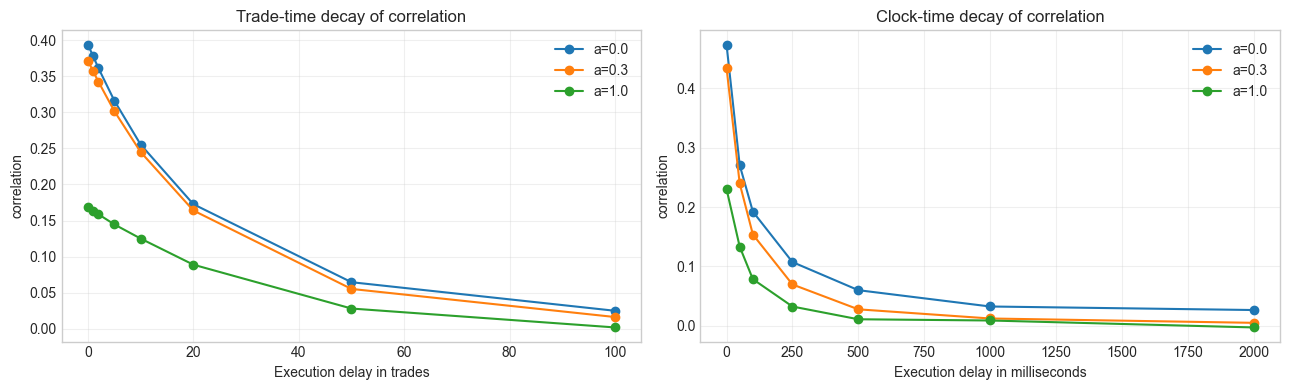

In [11]:
trade_plot = trade_decay_df[(trade_decay_df["signal_T"] == 10) & (trade_decay_df["return_H_trades"] == 10)].copy()
clock_plot = clock_decay_df[(clock_decay_df["signal_T"] == 10) & (clock_decay_df["return_H_ms"] == 1000)].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for a in [0.0, 0.3, 1.0]:
    tmp = trade_plot[trade_plot["a"] == a].sort_values("delay_trades")
    axes[0].plot(tmp["delay_trades"], tmp["corr"], marker="o", label=f"a={a}")

axes[0].set_title("Trade-time decay of correlation")
axes[0].set_xlabel("Execution delay in trades")
axes[0].set_ylabel("correlation")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

for a in [0.0, 0.3, 1.0]:
    tmp = clock_plot[clock_plot["a"] == a].sort_values("delay_ms")
    axes[1].plot(tmp["delay_ms"], tmp["corr"], marker="o", label=f"a={a}")

axes[1].set_title("Clock-time decay of correlation")
axes[1].set_xlabel("Execution delay in milliseconds")
axes[1].set_ylabel("correlation")
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

## Signal Strength After Delay

Direction is not enough. The next notebook step should check whether strong signals still imply materially larger moves after realistic execution delay.

Useful follow-on questions:

- does the top signal bucket still have positive average return after delay,
- how quickly does top-minus-bottom bucket spread collapse,
- is the trade-time decay slower or faster than the clock-time decay?